Loading California Housing Dataset...

--- Running Experiment 1: Base MLP ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Running Experiment 2: Enhanced MLP ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



FINAL EXPERIMENT COMPARISON
                        Loss (MSE)       MAE Activation     LR
Experiment 1 (Base)       0.296964  0.370833       relu   0.01
Experiment 2 (Enhanced)   0.309973  0.376966       tanh  0.001


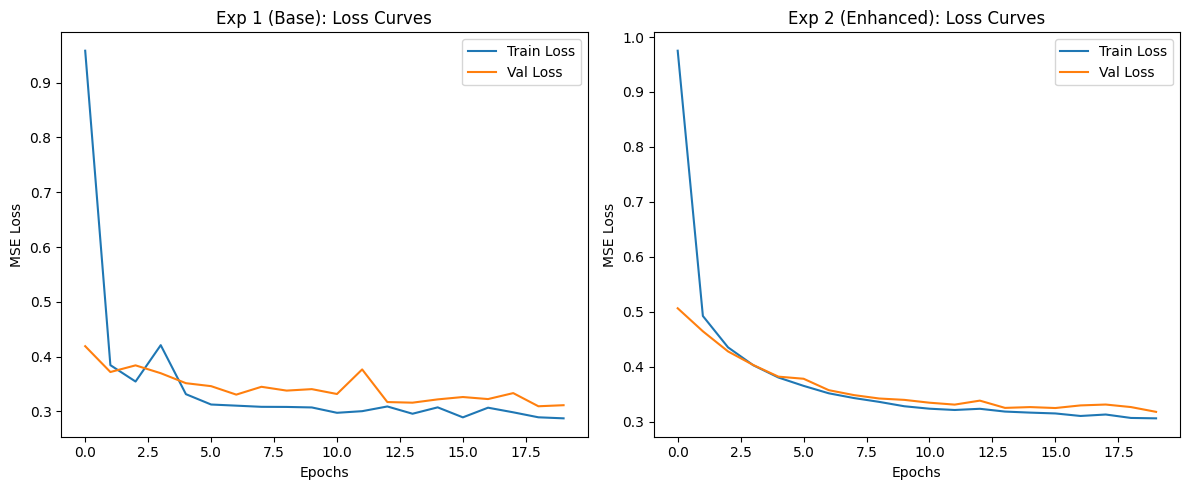

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Load and Preprocess Data
print("Loading California Housing Dataset...")
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization / Scaling (Requirement 2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to save results for comparison
results = {}


# EXPERIMENT 1: Base MLP Model

print("\n--- Running Experiment 1: Base MLP ---")
model_1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model_1.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
history_1 = model_1.fit(X_train_scaled, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=0)

loss_1, mae_1 = model_1.evaluate(X_test_scaled, y_test, verbose=0)
results['Experiment 1 (Base)'] = {'Loss (MSE)': loss_1, 'MAE': mae_1, 'Activation': 'relu', 'LR': 0.01}


# EXPERIMENT 2: Deeper Model + Regularization (Dropout) + Lower LR

print("\n--- Running Experiment 2: Enhanced MLP ---")
model_2 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train_scaled.shape[1],)), # Changed Activation
    Dropout(0.2), # Optional Enhancement (Requirement 8)
    Dense(32, activation='tanh'),
    Dense(16, activation='tanh'),
    Dense(1, activation='linear')
])

model_2.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae']) # Changed Learning Rate
history_2 = model_2.fit(X_train_scaled, y_train, validation_split=0.2, epochs=20, batch_size=32, verbose=0)

loss_2, mae_2 = model_2.evaluate(X_test_scaled, y_test, verbose=0)
results['Experiment 2 (Enhanced)'] = {'Loss (MSE)': loss_2, 'MAE': mae_2, 'Activation': 'tanh', 'LR': 0.001}


# 3. Print Comparison Table (Requirement 6)

print("\n" + "="*50)
print("FINAL EXPERIMENT COMPARISON")
print("="*50)
df_results = pd.DataFrame(results).T
print(df_results)


# 4. Visualization (Requirement 7)

plt.figure(figsize=(12, 5))

# Plot Experiment 1 Loss
plt.subplot(1, 2, 1)
plt.plot(history_1.history['loss'], label='Train Loss')
plt.plot(history_1.history['val_loss'], label='Val Loss')
plt.title('Exp 1 (Base): Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

# Plot Experiment 2 Loss
plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train Loss')
plt.plot(history_2.history['val_loss'], label='Val Loss')
plt.title('Exp 2 (Enhanced): Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.tight_layout()
plt.show()